In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch


In [3]:
df_tcga = pd.read_csv('./Fig7_data/DEG_tcga.csv')
df_cptac = pd.read_csv('./Fig7_data/DEG_cptac.csv')

In [6]:
df_tcga

,gene,inner_5,outer_5,tumor_all,tumor_core,sample,logFC_inner_vs_core,dataset
0,ALDH2,0.207560,0.066926,0.208038,0.287621,S11,0.470637,TCGA
1,BHLHE40,0.217736,0.091065,0.217552,0.186900,S11,-0.220312,TCGA
2,CLPTM1L,0.153204,0.054000,0.153362,0.179596,S11,0.229299,TCGA
3,CRIP1,0.204166,0.105057,0.204032,0.181697,S11,-0.168208,TCGA
4,CTSD,0.176159,0.084089,0.176065,0.160241,S11,-0.136641,TCGA
...,...,...,...,...,...,...,...,...
8491,JUNB,0.186504,0.103252,0.182596,0.180843,S541,-0.044475,TCGA
8492,PLD3,0.145611,0.059419,0.148843,0.150294,S541,0.045666,TCGA
8493,PPT1,0.104577,0.040698,0.105647,0.106127,S541,0.021237,TCGA
8494,SOCS3,0.103086,0.061385,0.103844,0.104184,S541,0.015280,TCGA


In [7]:
df_cptac

,patient_id,gene,logFC_inner_vs_core,dataset
0,C3L-00001,ALDH2,0.046967,CPTAC
1,C3L-00001,BHLHE40,-0.039308,CPTAC
2,C3L-00001,CLPTM1L,0.039295,CPTAC
3,C3L-00001,CRIP1,0.097778,CPTAC
4,C3L-00001,CTSD,0.186813,CPTAC
...,...,...,...,...
2907,C3N-04382,JUNB,-0.004532,CPTAC
2908,C3N-04382,PLD3,0.112922,CPTAC
2909,C3N-04382,PPT1,0.099966,CPTAC
2910,C3N-04382,SOCS3,-0.056034,CPTAC


In [8]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd

def compute_deg(df, logfc_col="logFC_inner_vs_core", min_samples=20):
    rows = []

    for gene, sub in df.groupby("gene"):
        vals = sub[logfc_col].dropna().values

        if len(vals) < min_samples:
            continue

        if np.allclose(vals, 0):
            p = 1.0
        else:
            try:
                _, p = wilcoxon(vals, zero_method="wilcox")
            except ValueError:
                p = 1.0

        rows.append({
            "gene": gene,
            "n_samples": len(vals),
            "median_logFC": np.median(vals),
            "mean_logFC": np.mean(vals),
            "pct_positive": np.mean(vals > 0),
            "pct_negative": np.mean(vals < 0),
            "p_value": p,
        })

    res = pd.DataFrame(rows)

    if res.shape[0] > 0:
        res["FDR"] = multipletests(res["p_value"], method="fdr_bh")[1]
        res = res.sort_values("FDR").reset_index(drop=True)

    return res

In [12]:
deg_tcga = compute_deg(df_tcga, logfc_col="logFC_inner_vs_core", min_samples=20)
print(deg_tcga)

       gene  n_samples  median_logFC  mean_logFC  pct_positive  pct_negative  \
0     SOCS3        531     -0.094266   -0.290383      0.190207      0.807910   
1     FUCA1        531      0.109550   -0.075064      0.800377      0.197740   
2      JUNB        531     -0.061000   -0.253486      0.192090      0.806026   
3      CTSD        531      0.099821   -0.089231      0.783427      0.214689   
4      PLD3        531      0.075037   -0.117459      0.770245      0.227872   
5      PPT1        531      0.082834   -0.105433      0.770245      0.227872   
6     DEPP1        531     -0.076292   -0.253460      0.239171      0.758945   
7   BHLHE40        531     -0.048359   -0.239835      0.256121      0.741996   
8     CRIP1        531      0.077572   -0.121087      0.740113      0.258004   
9       GRN        531      0.074100   -0.121543      0.732580      0.265537   
10  CLPTM1L        531      0.085272   -0.090871      0.723164      0.274953   
11  ZFP36L2        531     -0.046417   -

In [13]:
deg_cptac = compute_deg(df_cptac, logfc_col="logFC_inner_vs_core", min_samples=20)
print(deg_cptac)

       gene  n_samples  median_logFC  mean_logFC  pct_positive  pct_negative  \
0     SOCS3        182     -0.071289   -0.074306      0.164835      0.835165   
1     FUCA1        182      0.087036    0.086598      0.818681      0.181319   
2      PLD3        182      0.066922    0.069890      0.802198      0.197802   
3      JUNB        182     -0.049885   -0.043655      0.197802      0.802198   
4   BHLHE40        182     -0.046732   -0.044987      0.164835      0.835165   
5      CTSS        182      0.082481    0.085855      0.780220      0.219780   
6   ZFP36L2        182     -0.052667   -0.053597      0.192308      0.807692   
7      CTSD        182      0.074853    0.076826      0.791209      0.208791   
8     CRIP1        182      0.069533    0.067627      0.774725      0.225275   
9     DEPP1        182     -0.058234   -0.062245      0.247253      0.752747   
10     PPT1        182      0.065248    0.060129      0.730769      0.269231   
11      GRN        182      0.048260    

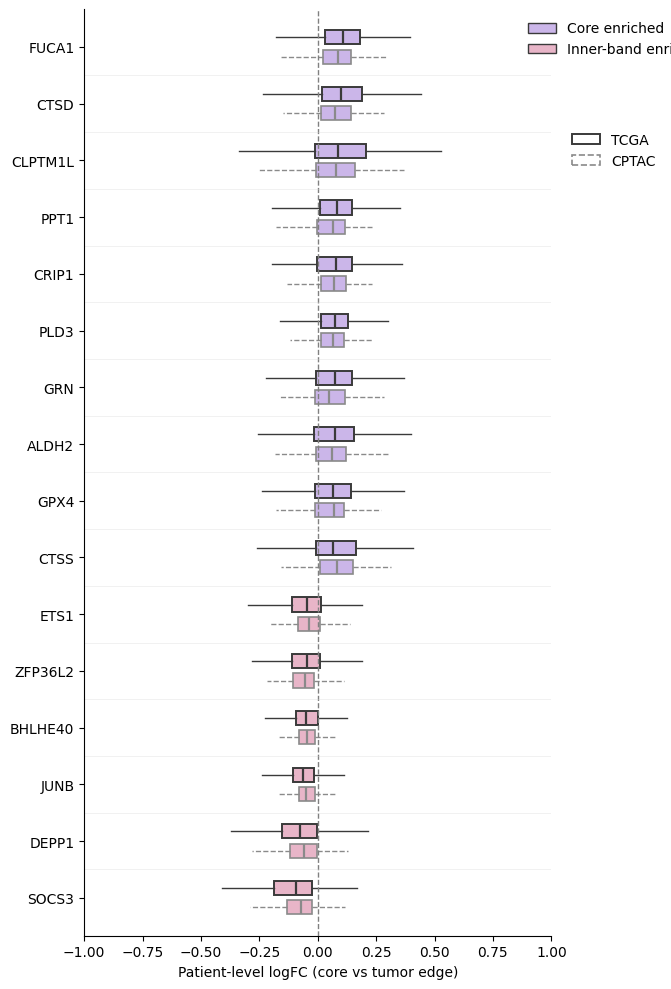

In [11]:
plot_df = pd.concat([df_tcga, df_cptac], axis=0).copy()

tcga_medians = (
    plot_df[plot_df["dataset"] == "TCGA"]
    .groupby("gene")["logFC_inner_vs_core"]
    .median()
    .sort_values(ascending=True)
)

sorted_genes = tcga_medians.index.tolist()

direction_colors = {
    "core": "#CBB6E9",
    "inner": "#E8B5C8",
}

medians = (
    plot_df
    .groupby(["gene", "dataset"])["logFC_inner_vs_core"]
    .median()
)


fig, ax = plt.subplots(figsize=(7, 10))

y_base = np.arange(len(sorted_genes))
offset = 0.17
box_width = 0.25

for i, gene in enumerate(sorted_genes):

    for dataset in ["TCGA", "CPTAC"]:

        if dataset == "TCGA":
            dy = +offset
            edge_color = "#3A3A3A"
            line_style = "-"
            line_width = 1.4
        else:
            dy = -offset
            edge_color = "#8A8A8A"
            line_style = "--"
            line_width = 1.2

        vals = plot_df.loc[
            (plot_df["gene"] == gene) &
            (plot_df["dataset"] == dataset),
            "logFC_inner_vs_core"
        ].dropna().values

        if len(vals) == 0:
            continue

        median_val = medians.loc[(gene, dataset)]
        direction = "core" if median_val > 0 else "inner"
        color = direction_colors[direction]

        ax.boxplot(
            vals,
            positions=[i + dy],
            vert=False,
            widths=box_width,
            patch_artist=True,
            showfliers=False,
            showcaps=False,
            boxprops=dict(
                facecolor=color,
                edgecolor=edge_color,
                linewidth=line_width,
                linestyle=line_style
            ),
            medianprops=dict(color=edge_color, linewidth=1.6),
            whiskerprops=dict(
                color=edge_color,
                linewidth=1,
                linestyle=line_style
            ),
            capprops=dict(linewidth=0)
        )


ax.axvline(0, linestyle="--", color="gray", linewidth=1)

ax.set_yticks(y_base)
ax.set_yticklabels(sorted_genes)

ax.set_xlim(-1, 1)
ax.set_xlabel("Patient-level logFC (core vs tumor edge)")
ax.set_ylabel("")
ax.set_title("")

for i in range(len(sorted_genes) - 1):
    ax.axhline(i + 0.5, color="lightgray", lw=0.5, alpha=0.45)


direction_legend = [
    Patch(facecolor=direction_colors["core"], edgecolor="#3A3A3A", label="Core enriched"),
    Patch(facecolor=direction_colors["inner"], edgecolor="#3A3A3A", label="Inner-band enriched"),
]

dataset_legend = [
    Patch(
        facecolor="white",
        edgecolor="#3A3A3A",
        linewidth=1.4,
        linestyle="-",
        label="TCGA"
    ),
    Patch(
        facecolor="white",
        edgecolor="#8A8A8A",
        linewidth=1.2,
        linestyle="--",
        label="CPTAC"
    ),
]

leg1 = ax.legend(
    handles=direction_legend,
    frameon=False,
    loc="upper right",
    bbox_to_anchor=(1.36, 1.00)
)

ax.add_artist(leg1)

ax.legend(
    handles=dataset_legend,
    frameon=False,
    loc="upper right",
    bbox_to_anchor=(1.25, 0.88)
)

# 美化
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

# plt.savefig(
#     "./All_fig7/Bio_discovery/Core_inner_DEG.pdf",
#     format="pdf",
#     bbox_inches="tight"
# )

plt.show()